# **TUẦN 1: 2.1 + 2.2**

In [ ]:
# Cài PySpark (tự lo luôn Spark + Java)
!pip install pyspark -q

# Khởi tạo SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Final") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

print("✅ Spark đã sẵn sàng!")

✅ Spark đã sẵn sàng!


In [ ]:
!pip install -q streamlit
print("\nStreamlit installed successfully.")


Streamlit installed successfully.


In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip install -q gradio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/datasetCuoiKy/"

In [ ]:
# Đọc dữ liệu
orders_df = spark.read.csv(base_path + "olist_orders_dataset.csv", header=True, inferSchema=True)
customers_df = spark.read.csv(base_path + "olist_customers_dataset.csv", header=True, inferSchema=True)
order_items_df = spark.read.csv(base_path + "olist_order_items_dataset.csv", header=True, inferSchema=True)
payments_df = spark.read.csv(base_path + "olist_order_payments_dataset.csv", header=True, inferSchema=True)
reviews_df = spark.read.csv(base_path + "olist_order_reviews_dataset.csv", header=True, inferSchema=True)
products_df = spark.read.csv(base_path + "olist_products_dataset.csv", header=True, inferSchema=True)
sellers_df = spark.read.csv(base_path + "olist_sellers_dataset.csv", header=True, inferSchema=True)
category_df = spark.read.csv(base_path + "product_category_name_translation.csv", header=True, inferSchema=True)
geolocation_df = spark.read.csv(base_path + "olist_geolocation_dataset.csv", header=True, inferSchema=True)
print("Đã đọc xong 9 file CSV")

Đã đọc xong 9 file CSV


In [ ]:
from pyspark.sql.functions import col, sum

def explore_full(df, name):
    print("\n==============================")
    print("DATASET:", name)
    print("==============================")

    # 1. Số dòng
    total_rows = df.count()
    print("Số dòng:", total_rows)

    # 2. Schema
    print("\nSchema:")
    df.printSchema()

    # 3. Dữ liệu mẫu
    print("\n5 dòng đầu:")
    df.show(5, truncate=False)

    # 4. Thống kê mô tả
    print("\nThống kê:")
    df.describe().show()

    # 5. Kiểm tra null
    print("\nSố lượng NULL theo cột:")
    null_df = df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])
    null_df.show()

    # 6. Kiểm tra duplicate
    unique_rows = df.dropDuplicates().count()
    print("\nDuplicate:")
    print("Tổng:", total_rows)
    print("Unique:", unique_rows)
    print("Số dòng trùng:", total_rows - unique_rows)

In [ ]:
explore_full(customers_df, "customers")


DATASET: customers
Số dòng: 99441

Schema:
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|06b8999e2fba1a1fbc88172c00ba8bc7|861eff4711a542e4b93843c6dd7febb0|14409                   |franca               |SP            |
|18955e83d337fd6b2def6b18a428ac77|290c77bc529b7ac935b93aa66c333dc3|9790                    |sao bernardo do campo|SP            |
|4e7b3e00288586ebd08712fdd0374a03|060e732b5b29

In [ ]:
explore_full(geolocation_df, "geolocation")


DATASET: geolocation
Số dòng: 1000163

Schema:
root
 |-- geolocation_zip_code_prefix: integer (nullable = true)
 |-- geolocation_lat: double (nullable = true)
 |-- geolocation_lng: double (nullable = true)
 |-- geolocation_city: string (nullable = true)
 |-- geolocation_state: string (nullable = true)


5 dòng đầu:
+---------------------------+-------------------+------------------+----------------+-----------------+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng   |geolocation_city|geolocation_state|
+---------------------------+-------------------+------------------+----------------+-----------------+
|1037                       |-23.54562128115268 |-46.63929204800168|sao paulo       |SP               |
|1046                       |-23.546081127035535|-46.64482029837157|sao paulo       |SP               |
|1046                       |-23.54612896641469 |-46.64295148361138|sao paulo       |SP               |
|1041                       |-23.5443921648681  |-46.63949

In [ ]:
explore_full(order_items_df, "order_items")


DATASET: order_items
Số dòng: 112650

Schema:
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price|freight_value|
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1ba2dd792cb16214|1            |4244733e06e7ecb4970a6e2683c13e61|48436dade18ac8b2bce089ec2a041202|2017-09-19 09:45:35|58.9 |13.29        |
|00018f77

In [ ]:
explore_full(payments_df, "payments")


DATASET: payments
Số dòng: 103886

Schema:
root
 |-- order_id: string (nullable = true)
 |-- payment_sequential: integer (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: integer (nullable = true)
 |-- payment_value: double (nullable = true)


5 dòng đầu:
+--------------------------------+------------------+------------+--------------------+-------------+
|order_id                        |payment_sequential|payment_type|payment_installments|payment_value|
+--------------------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b1e8b2acac839d17|1                 |credit_card |8                   |99.33        |
|a9810da82917af2d9aefd1278f1dcfa0|1                 |credit_card |1                   |24.39        |
|25e8ea4e93396b6fa0d3dd708e76c1bd|1                 |credit_card |1                   |65.71        |
|ba78997921bbcdc1373bb41e913ab953|1                 |credit_card |8                   |107.7

In [ ]:
explore_full(reviews_df, "reviews")


DATASET: reviews
Số dòng: 104162

Schema:
root
 |-- review_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- review_score: string (nullable = true)
 |-- review_comment_title: string (nullable = true)
 |-- review_comment_message: string (nullable = true)
 |-- review_creation_date: string (nullable = true)
 |-- review_answer_timestamp: string (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+--------------------+-----------------------+
|review_id                       |order_id                        |review_score|review_comment_title|review_comment_message                                                                              |review_creation_date|review_answer_timestamp|
+--------------------------------+--------------------------------+------------+--------------------+---

In [ ]:
explore_full(orders_df, "orders")


DATASET: orders
Số dòng: 99441

Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


5 dòng đầu:
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+-

In [ ]:
explore_full(products_df, "products")


DATASET: products
Số dòng: 32951

Schema:
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: integer (nullable = true)
 |-- product_description_lenght: integer (nullable = true)
 |-- product_photos_qty: integer (nullable = true)
 |-- product_weight_g: integer (nullable = true)
 |-- product_length_cm: integer (nullable = true)
 |-- product_height_cm: integer (nullable = true)
 |-- product_width_cm: integer (nullable = true)


5 dòng đầu:
+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------------------+---------------------+-------------------+---------------------

In [ ]:
explore_full(sellers_df, "sellers")


DATASET: sellers
Số dòng: 3095

Schema:
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)


5 dòng đầu:
+--------------------------------+----------------------+-----------------+------------+
|seller_id                       |seller_zip_code_prefix|seller_city      |seller_state|
+--------------------------------+----------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb2df15|13023                 |campinas         |SP          |
|d1b65fc7debc3361ea86b5f14c68d2e2|13844                 |mogi guacu       |SP          |
|ce3ad9de960102d0677a81f5d0bb7b2d|20031                 |rio de janeiro   |RJ          |
|c0f3eea2e14555b6faeea3dd58c1b1c3|4195                  |sao paulo        |SP          |
|51a04a8a6bdcb23deccc82b0b80742cf|12914                 |braganca paulista|SP          |
+--------------------------------+-----------

In [ ]:
explore_full(category_df, "category_translation")


DATASET: category_translation
Số dòng: 71

Schema:
root
 |-- product_category_name: string (nullable = true)
 |-- product_category_name_english: string (nullable = true)


5 dòng đầu:
+----------------------+-----------------------------+
|product_category_name |product_category_name_english|
+----------------------+-----------------------------+
|beleza_saude          |health_beauty                |
|informatica_acessorios|computers_accessories        |
|automotivo            |auto                         |
|cama_mesa_banho       |bed_bath_table               |
|moveis_decoracao      |furniture_decor              |
+----------------------+-----------------------------+
only showing top 5 rows

Thống kê:
+-------+---------------------+-----------------------------+
|summary|product_category_name|product_category_name_english|
+-------+---------------------+-----------------------------+
|  count|                   71|                           71|
|   mean|                 NULL|      

# **TUẦN 1: 2.4.Tiền xử lý dữ liệu**

In [ ]:
from pyspark.sql.functions import *

In [ ]:
from pyspark.sql import SparkSession

# Khởi tạo Spark session
spark = SparkSession.builder \
    .appName("Olist_Load_Parquet") \
    .getOrCreate()

# Đường dẫn file
file_path = "/content/drive/MyDrive/datasetCuoiKy/olist_master_processed.parquet"

# Đọc file Parquet
df_master = spark.read.parquet(file_path)

### **CLASSIFICATION**

CODE PHỤ: ĐÃ THÊM CROSS VALIDATION

In [ ]:
# ==============================
# 1. PREPROCESS (FIX NHẸ)
# ==============================
from pyspark.sql.functions import when, col

df_ml = df_master.filter(col("review_score").isNotNull())

df_ml = df_ml.withColumn(
    "label",
    when(col("review_score") <= 3, 0).otherwise(1)
)

# FIX leakage: xử lý trước khi split
df_ml = df_ml.withColumn(
    "delivery_delay_days",
    when(col("delivery_delay_days") < 0, 0)
    .otherwise(col("delivery_delay_days"))
)

df_ml = df_ml.fillna({
    "delivery_delay_days": 0,
    "total_freight_value": 0,
    "total_price": 0,
    "num_items": 0,
    "product_weight_g": 0,
    "is_late_delivery": 0,
    "product_photos_qty": 0,
    "product_category_name_english": "unknown",
    "payment_type": "unknown",
    "customer_state": "unknown",
    "seller_state": "unknown"
})

In [ ]:
# ==============================
# 2. FEATURE PIPELINE (KHÔNG LẶP)
# ==============================
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, ChiSqSelector

categorical_cols = ["payment_type", "product_category_name_english", "customer_state", "seller_state"]

indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_vec")
    for c in categorical_cols
]

numeric_cols = [
    "total_freight_value",
    "total_price",
    "num_items",
    "delivery_delay_days",
    "product_weight_g",
    "is_late_delivery",
    "product_photos_qty"
]

feature_cols = numeric_cols + [c + "_vec" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

selector = ChiSqSelector(
    numTopFeatures=30,
    featuresCol="features",
    outputCol="selected_features",
    labelCol="label"
)

# PIPELINE CHUNG
from pyspark.ml import Pipeline
base_pipeline = Pipeline(stages=indexers + encoders + [assembler, selector])


In [ ]:
# ==============================
# 3. SPLIT DATA
# ==============================
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# ==============================
# 4. CROSS VALIDATION SETUP
# ==============================
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import time

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

In [ ]:
# ==============================
# 5. TRAIN FUNCTION (TRÁNH LẶP CODE)
# ==============================
def train_with_cv(model, paramGrid, name):
    pipeline = Pipeline(stages=base_pipeline.getStages() + [model])

    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=paramGrid,
        evaluator=evaluator,
        numFolds=5
    )

    start = time.time()
    cv_model = cv.fit(train_df)
    train_time = time.time() - start

    pred = cv_model.transform(test_df)

    return cv_model, pred, train_time, name

In [ ]:
# ==============================
# 6. TRAIN ALL MODELS
# ==============================

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, NaiveBayes, LinearSVC, GBTClassifier

# Logistic Regression
lr = LogisticRegression(featuresCol="selected_features", labelCol="label")
param_lr = (ParamGridBuilder()
    .addGrid(lr.regParam, [0.001, 0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 0.5])
    .addGrid(lr.maxIter, [50, 100])
    .build())

model_lr, pred_lr, time_lr, name_lr = train_with_cv(lr, param_lr, "Logistic Regression")


In [ ]:
# Random Forest
rf = RandomForestClassifier(featuresCol="selected_features", labelCol="label")
param_rf = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [8, 12])
    .addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"])
    .build())

model_rf, pred_rf, time_rf, name_rf = train_with_cv(rf, param_rf, "Random Forest")



In [ ]:
# Naive Bayes
nb = NaiveBayes(featuresCol="selected_features", labelCol="label")
param_nb = (ParamGridBuilder()
    .addGrid(nb.smoothing, [0.5, 1.0, 1.5])
    .build())

model_nb, pred_nb, time_nb, name_nb = train_with_cv(nb, param_nb, "Naive Bayes")


In [ ]:
# Linear SVC
svc = LinearSVC(featuresCol="selected_features", labelCol="label")
param_svc = (ParamGridBuilder()
    .addGrid(svc.regParam, [0.01, 0.1, 1.0])
    .addGrid(svc.maxIter, [50, 100])
    .build())

model_svc, pred_svc, time_svc, name_svc = train_with_cv(svc, param_svc, "LinearSVC")



In [ ]:
# GBT
gbt = GBTClassifier(featuresCol="selected_features", labelCol="label")
param_gbt = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.maxIter, [20, 30])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build())

model_gbt, pred_gbt, time_gbt, name_gbt = train_with_cv(gbt, param_gbt, "GBTClassifier")


In [ ]:
print("\n===== BEST PARAMS =====")

def print_best_params(cv_model, model_name):
    print(f"\n🔹 {model_name}")

    best_model = cv_model.bestModel.stages[-1]
    # stages[-1] = model cuối (lr, rf, nb, ...)

    param_map = best_model.extractParamMap()

    for param, value in param_map.items():
        print(f"{param.name}: {value}")


# In từng model
print_best_params(model_lr, "Logistic Regression")
print_best_params(model_rf, "Random Forest")
print_best_params(model_nb, "Naive Bayes")
print_best_params(model_svc, "LinearSVC")
print_best_params(model_gbt, "GBTClassifier")


===== BEST PARAMS =====

🔹 Logistic Regression
aggregationDepth: 2
elasticNetParam: 0.5
family: auto
featuresCol: selected_features
fitIntercept: True
labelCol: label
maxBlockSizeInMB: 0.0
maxIter: 100
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
regParam: 0.001
standardization: True
threshold: 0.5
tol: 1e-06

🔹 Random Forest
bootstrap: True
cacheNodeIds: False
checkpointInterval: 10
featureSubsetStrategy: sqrt
featuresCol: selected_features
impurity: gini
labelCol: label
leafCol: 
maxBins: 32
maxDepth: 12
maxMemoryInMB: 256
minInfoGain: 0.0
minInstancesPerNode: 1
minWeightFractionPerNode: 0.0
numTrees: 100
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
seed: 4917030357113979094
subsamplingRate: 1.0

🔹 Naive Bayes
featuresCol: selected_features
labelCol: label
modelType: multinomial
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
smoothing: 1.0

🔹 LinearSVC
aggregation

In [ ]:
# ==============================
# 7. EVALUATION
# ==============================
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def evaluate_full(pred, name, train_time):
    # Đánh giá các metric
    acc = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(pred)

    precision = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedPrecision"
    ).evaluate(pred)

    recall = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedRecall"
    ).evaluate(pred)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    ).evaluate(pred)

    # AUC-ROC (dùng evaluator đã khai báo trước đó)
    auc = evaluator.evaluate(pred)

    # In kết quả
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("AUC-ROC:", auc)
    print("Train time:", train_time)

    # Trả về list kết quả (giữ nguyên thứ tự)
    return [name, acc, precision, recall, f1, auc, train_time]

In [ ]:
results = []
results.append(evaluate_full(pred_lr, name_lr, time_lr))
results.append(evaluate_full(pred_rf, name_rf, time_rf))
results.append(evaluate_full(pred_nb, name_nb, time_nb))
results.append(evaluate_full(pred_svc, name_svc, time_svc))
results.append(evaluate_full(pred_gbt, name_gbt, time_gbt))


Logistic Regression
Accuracy: 0.8040147103892124
Precision: 0.7884426731452318
Recall: 0.8040147103892124
F1-score: 0.7655971695041681
AUC-ROC: 0.6719300696896682
Train time: 712.2122204303741

Random Forest
Accuracy: 0.8089181734600062
Precision: 0.8105716456574203
Recall: 0.8089181734600062
F1-score: 0.762624376686582
AUC-ROC: 0.6791726916417917
Train time: 2274.891453742981

Naive Bayes
Accuracy: 0.8017672898150986
Precision: 0.7853330380951097
Recall: 0.8017672898150986
F1-score: 0.761520651702325
AUC-ROC: 0.5281262621832612
Train time: 229.36296725273132

LinearSVC
Accuracy: 0.7716825007661661
Precision: 0.7501791579292267
Recall: 0.7716825007661661
F1-score: 0.6753902299371068
AUC-ROC: 0.6512729446704595
Train time: 1446.0311193466187

GBTClassifier
Accuracy: 0.80850955153744
Precision: 0.8087766125227056
Recall: 0.80850955153744
F1-score: 0.7625496940009957
AUC-ROC: 0.679588467487561
Train time: 1645.8862612247467


In [ ]:
# ==============================
# 8. BEST MODEL
# ==============================
best_result = results[0]

for r in results:
    if r[4] > best_result[4]:
        best_result = r

best_model_name = best_result[0]
best_model_name = best_result[0]

print("\nBest model:", best_model_name)

model_dict = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "Naive Bayes": model_nb,
    "LinearSVC": model_svc,
    "GBTClassifier": model_gbt
}

best_model = model_dict[best_model_name]

# SAVE
save_path = "/content/drive/MyDrive/models/best_model.2"
best_model.write().overwrite().save(save_path)
print("✅ Saved!")


Best model: Logistic Regression
✅ Saved!


In [ ]:
def check_overfitting(cv_model, train_df, test_df, model_name):
    print(f"\n===== {model_name} =====")

    # Predict train
    pred_train = cv_model.transform(train_df)

    # Predict test
    pred_test = cv_model.transform(test_df)

    # Evaluate
    train_metrics = evaluate_full(pred_train, "train", 0)[1:6]
    test_metrics = evaluate_full(pred_test, "test", 0)[1:6]


    metric_names = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

    print("\n--- TRAIN ---")
    for name, val in zip(metric_names, train_metrics):
        print(f"{name}: {val:.4f}")

    print("\n--- TEST ---")
    for name, val in zip(metric_names, test_metrics):
        print(f"{name}: {val:.4f}")

    print("\n--- GAP (Train - Test) ---")
    for name, tr, te in zip(metric_names, train_metrics, test_metrics):
        print(f"{name}: {(tr - te):.4f}")

In [ ]:
check_overfitting(model_lr, train_df, test_df, "Logistic Regression")
check_overfitting(model_rf, train_df, test_df, "Random Forest")
check_overfitting(model_nb, train_df, test_df, "Naive Bayes")
check_overfitting(model_svc, train_df, test_df, "LinearSVC")
check_overfitting(model_gbt, train_df, test_df, "GBTClassifier")


===== Logistic Regression =====

train
Accuracy: 0.8033883304886529
Precision: 0.7862532808046625
Recall: 0.8033883304886529
F1-score: 0.7657959575985378
AUC-ROC: 0.6752914499418344
Train time: 0

test
Accuracy: 0.8040147103892124
Precision: 0.7884426731452318
Recall: 0.8040147103892124
F1-score: 0.7655971695041681
AUC-ROC: 0.6719278713007034
Train time: 0

--- TRAIN ---
Accuracy: 0.8034
Precision: 0.7863
Recall: 0.8034
F1: 0.7658
AUC: 0.6753

--- TEST ---
Accuracy: 0.8040
Precision: 0.7884
Recall: 0.8040
F1: 0.7656
AUC: 0.6719

--- GAP (Train - Test) ---
Accuracy: -0.0006
Precision: -0.0022
Recall: -0.0006
F1: 0.0002
AUC: 0.0034

===== Random Forest =====

train
Accuracy: 0.8133889626398635
Precision: 0.8181156259993401
Recall: 0.8133889626398634
F1-score: 0.7691462990842772
AUC-ROC: 0.7106575982358381
Train time: 0

test
Accuracy: 0.8089181734600062
Precision: 0.8105716456574203
Recall: 0.8089181734600062
F1-score: 0.762624376686582
AUC-ROC: 0.67918233356923
Train time: 0

--- TRAIN

          Pred 0  Pred 1
Actual 0    1117    3376
Actual 1     461   14624


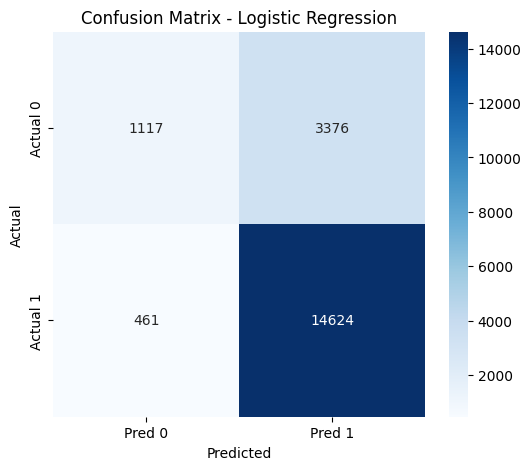


Đã lưu hình Confusion Matrix tại: /content/drive/MyDrive/models/confusion_matrix_rf.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================
# CONFUSION MATRIX (BEST MODEL)
# ============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔥 QUAN TRỌNG: tạo prediction từ best model
pred_best = best_model.transform(test_df)

# Convert Spark -> Pandas
pdf = pred_best.select("label", "prediction").toPandas()

# Ép kiểu
pdf["label"] = pdf["label"].astype(int)
pdf["prediction"] = pdf["prediction"].round().astype(int)

# Confusion Matrix
cm = confusion_matrix(pdf["label"], pdf["prediction"])

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

print(cm_df)

# Vẽ
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Lưu hình
save_path = "/content/drive/MyDrive/models/confusion_matrix_rf.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"\nĐã lưu hình Confusion Matrix tại: {save_path}")

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

TP: 14624
TN: 1117
FP: 3376
FN: 461


In [ ]:
# ==============================
# VI.6 – Model Evaluation & Analysis
# ==============================

from pyspark.sql.functions import col, when
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# 2. Class distribution
# -----------------------------
print("=== Class distribution (label) ===")
df_ml.groupBy("label").count().show()

total_count = df_ml.count()
df_ml.groupBy("label").count() \
     .withColumn("percentage", col("count")/total_count*100) \
     .show()
# 3. Evaluate all models (assuming 'results' chứa output training)
import pandas as pd
# Chuyển sang DataFrame Pandas để dễ xử lý
df_results = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1","AUC","Train_time"])
print("=== All models metrics ===")
print(df_results)

# -----------------------------
# 4. Chọn Best Model dựa trên F1-score
# -----------------------------
if len(results) == 0:
    print("⚠️ Chưa có kết quả model. Hãy chạy lại phần training + evaluation.")
else:
    best_result = max(results, key=lambda x: x[4])
    best_model_name = best_result[0]
    print(f"=== Best model by F1-score: {best_model_name} ===")
    print(best_result)

    # -----------------------------
    # 5. Plot
    # -----------------------------
    import matplotlib.pyplot as plt

    df_results.plot(
        x="Model",
        y=["Accuracy","Precision","Recall","F1","AUC"],
        kind="bar",
        figsize=(12,6)
    )
    plt.title("Comparison of Models Metrics")
    plt.ylabel("Score")
    plt.ylim(0,1)
    plt.show()

=== Class distribution (label) ===
+-----+-----+
|label|count|
+-----+-----+
|    1|76063|
|    0|22610|
+-----+-----+

+-----+-----+------------------+
|label|count|        percentage|
+-----+-----+------------------+
|    1|76063| 77.08593029501485|
|    0|22610|22.914069704985152|
+-----+-----+------------------+

=== All models metrics ===
Empty DataFrame
Columns: [Model, Accuracy, Precision, Recall, F1, AUC, Train_time]
Index: []
⚠️ Chưa có kết quả model. Hãy chạy lại phần training + evaluation.
